In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## Metode Iteratif.

kita akan membahas sejumlah metode klasik dan metode yang lebih modern untuk menyelesaikan sistem linear jarang (sparse) seperti yang kita peroleh dari pembahasan masalah nilai batas.

## Cara-cara untuk Menyelesaikan $(A u = f)$.


Kita telah mengusulkan untuk menyelesaikan sistem linear $(A u = f)$ yang sebelumnya kita implementasikan secara sederhana (naif) menggunakan perintah `numpy.linalg.solve`, tetapi mungkin dengan mempertimbangkan struktur khusus dari matriks $(A)$ di sini, kita dapat melakukannya dengan cara yang lebih baik.


## Metode Langsung (Eliminasi Gauss)

Kita dapat menggunakan eliminasi Gauss untuk menyelesaikan sistem tersebut (atau menggunakan suatu faktorisasi), yang menghasilkan solusi dalam sejumlah langkah yang terbatas.
Namun, untuk sistem yang besar dan jarang (sparse), metode langsung ini pada umumnya lebih mahal secara komputasi dibandingkan dengan metode iteratif.
Seperti yang telah dibahas pada masalah nilai eigen, metode iteratif dimulai dengan tebakan awal (initial guess) dan kemudian berusaha memperbaiki tebakan tersebut secara bertahap.

## Beban Komputasi

Sekarang perhatikan penggunaan eliminasi Gauss pada matriks di atas. Sebagai contoh, kita pertimbangkan masalah 3 dimensi dan mendiskretisasi setiap dimensi dengan $(N = 100)$, sehingga diperoleh
$
m = 100 \times 100 \times 100 = 10^6
$
variabel tak diketahui (unknowns). Eliminasi Gauss memerlukan sekitar
$
\mathcal{O}(m^3)
$
operasi untuk menyelesaikan sistem tersebut, sehingga
$
(10^6)^3 = 10^{18}
$
operasi.

Misalkan kita memiliki komputer yang mampu melakukan 100 gigaflops (operasi floating point per detik):

$$
\frac{10^{18}~ [\text{flop}]}{10^{11}~ [\text{flop / s}]} = 10^7~\text{s} \approx 115~\text{hari}.
$$

Artinya, penyelesaian dengan metode ini dapat memakan waktu sekitar 115 hari.

## Beban Memori

Bagaimana dengan kebutuhan memori?

Kita memerlukan $m^2$ untuk menyimpan seluruh elemen matriks. Jika menggunakan floating point double precision, setiap elemen memerlukan 8 byte, sehingga diperoleh

$$
(10^6)^2 ; [\text{elemen}] \times 8 ; [\text{byte/elemen}]
= 8 \times 10^{12} ; [\text{byte}]
= 8 ; \text{terabyte}.
$$

Artinya, untuk menyimpan matriks tersebut dibutuhkan sekitar 8 terabyte memori.

Sebenarnya keadaannya tidak seburuk yang kita gambarkan selama kita memanfaatkan sifat jarang dari matriks tersebut. Bahkan untuk masalah satu dimensi, metode langsung dapat dikurangi menjadi $\mathcal{O}(N)$ dalam kasus sistem tridiagonal. Namun, untuk masalah berdimensi lebih tinggi, keadaannya tidak sebaik itu kecuali jika ada struktur tambahan yang dapat dimanfaatkan. Contoh dari jenis penyelesai (solver) seperti ini termasuk metode Fourier cepat, seperti fast Poisson solvers.

## Metode Iteratif

Metode iteratif menggunakan pendekatan yang berbeda dibandingkan dengan metode langsung. Jika kita memiliki sistem
$
A x = b
$
kita membentuk suatu prosedur iteratif dengan menerapkan sebuah fungsi, misalnya $L$, sehingga

$$
\hat{x}^{(k)} = L(\hat{x}^{(k-1)})
$$

di mana kita menginginkan galat (error) antara solusi sebenarnya $x$ dan $\hat{x}^{(k)}$ menuju nol ketika $k \rightarrow \infty$.

## Metode Jacobi dan Gauss–Seidel

Metode Jacobi dan Gauss–Seidel merupakan pendekatan sederhana untuk memperkenalkan cara iteratif dalam menyelesaikan masalah $Ax = b$ ketika matriks $A$ bersifat jarang (sparse). 
Perhatikan kembali masalah Poisson
$
u_{xx} = f(x)
$
dan pendekatan beda hingga (finite difference) pada titik $x_i$

$$
\frac{U_{i-1} - 2U_i + U_{i+1}}{\Delta x^2} = f(x_i).
$$

Jika kita menyusun ulang persamaan ini untuk mencari $U_i$, maka diperoleh

$$
U_i = \frac{1}{2} (U_{i+1} + U_{i-1}) - f(x_i) \frac{\Delta x^2}{2}.
$$

Pada metode langsung, kita akan menentukan secara bersamaan nilai $U_i$, $U_{i+1}$, dan $U_{i-1}$. Namun, pada skema iteratif, kita menghitung pembaruan dari persamaan di atas dengan menggunakan iterasi sebelumnya (nilai yang sudah kita ketahui):

$$
U_i^{(k+1)} = \frac{1}{2}\left(U_{i+1}^{(k)} + U_{i-1}^{(k)}\right) - f(x_i)\frac{\Delta x^2}{2}.
$$

Karena persamaan ini memungkinkan kita menghitung $U_i^{(k+1)}$ tanpa harus mengetahui nilai baru $U_{i+1}^{(k+1)}$ dan $U_{i-1}^{(k+1)}$, kita dapat langsung mengevaluasi persamaan tersebut menggunakan nilai iterasi sebelumnya. Proses ini disebut iterasi Jacobi.
Dapat ditunjukkan bahwa untuk masalah khusus ini, iterasi Jacobi akan konvergen dari tebakan awal apa pun $U^{(0)}$, meskipun konvergensinya relatif lambat.

Keuntungan:
* Matriks $A$ tidak perlu disimpan atau bahkan dibuat.
* Kebutuhan penyimpanan menjadi optimal.
* Diperlukan sekitar $\mathcal{O}(m)$ operasi pada setiap iterasi, di mana $m$ adalah jumlah variabel yang tidak diketahui.


## Contoh

Mari kita coba menyelesaikan masalah sebelumnya pada bagian masalah nilai batas, tetapi kali ini menggunakan iterasi Jacobi untuk menggantikan metode penyelesaian langsung.

$$
u_{xx} = e^x, \quad x \in [0, 1] \quad \text{dengan} \quad u(0) = 0.0, \text{ dan } u(1) = 3.
$$


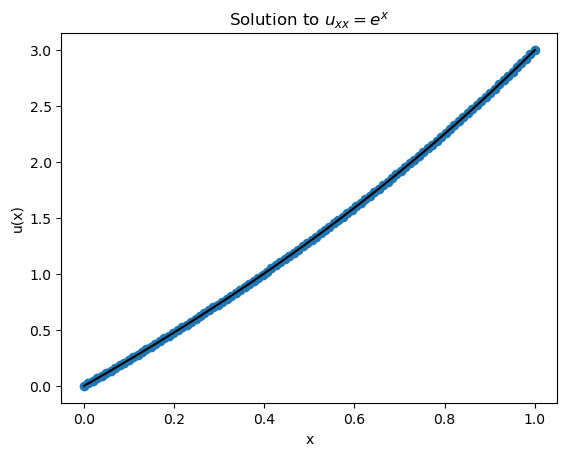

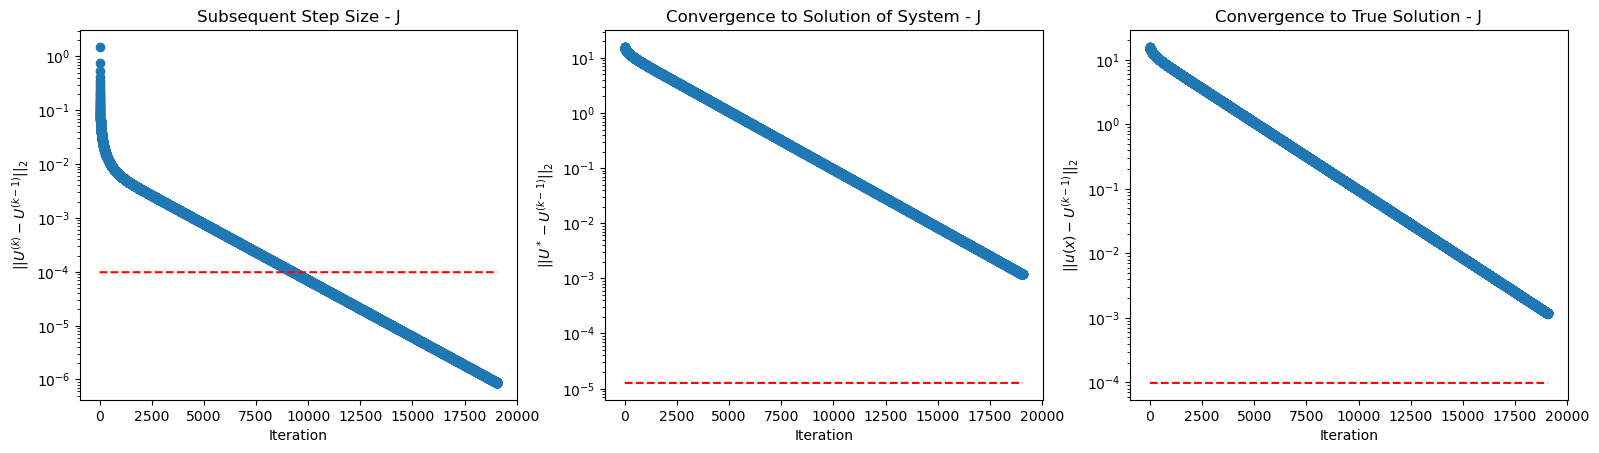

In [3]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

def U_true(a, b, u_a, u_b, f, m):
    """Compute the solution to the given linear system"""
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)
    
    # Construct matrix A
    A = numpy.zeros((m, m))
    diagonal = numpy.ones(m) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x)
    b[0] -= u_a / delta_x**2
    b[-1] -= u_b / delta_x**2

    # Solve system
    U = numpy.empty(m + 2)
    U[0] = u_a
    U[-1] = u_b
    U[1:-1] = numpy.linalg.solve(A, b)
    
    return U

# Descretization
m = 100
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Expected iterations needed
iterations_J = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 0.5 * numpy.pi**2 * delta_x**2))

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# Initial guess for iterations
U_new = numpy.zeros(m + 2)
U_new[0] = u_a
U_new[-1] = u_b
convergence_J = numpy.zeros((iterations_J, 2))
step_size_J = numpy.zeros(iterations_J)
for k in range(iterations_J):
    U = U_new.copy()
    for i in range(1, m + 1):
        U_new[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0

    step_size_J[k] = numpy.linalg.norm(U - U_new, ord=2)
    convergence_J[k, 0] = numpy.linalg.norm(U_system - U_new, ord=2)
    convergence_J[k, 1] = numpy.linalg.norm(u_true(x_bc) - U_new, ord=2)
        
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_J)), step_size_J, 'o')
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_J)), convergence_J[:, 0], 'o')
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_J)), convergence_J[:, 1], 'o')
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

Dengan sedikit modifikasi dari metode di atas, kita juga dapat memperoleh metode Gauss–Seidel. Secara pemrograman perubahan ini mudah dilihat, tetapi pada proses iterasi di atas sekarang kita memiliki

$$
U_i^{(k+1)} = \frac{1}{2}\left(U_{i+1}^{(k)} + U_{i-1}^{(k+1)}\right) - f(x_i)\frac{\Delta x^2}{2}.
$$


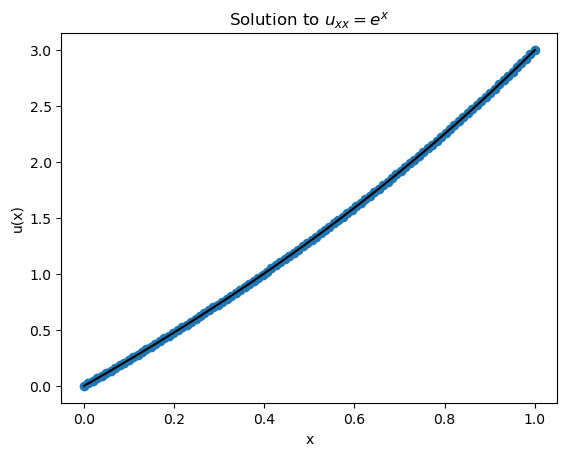

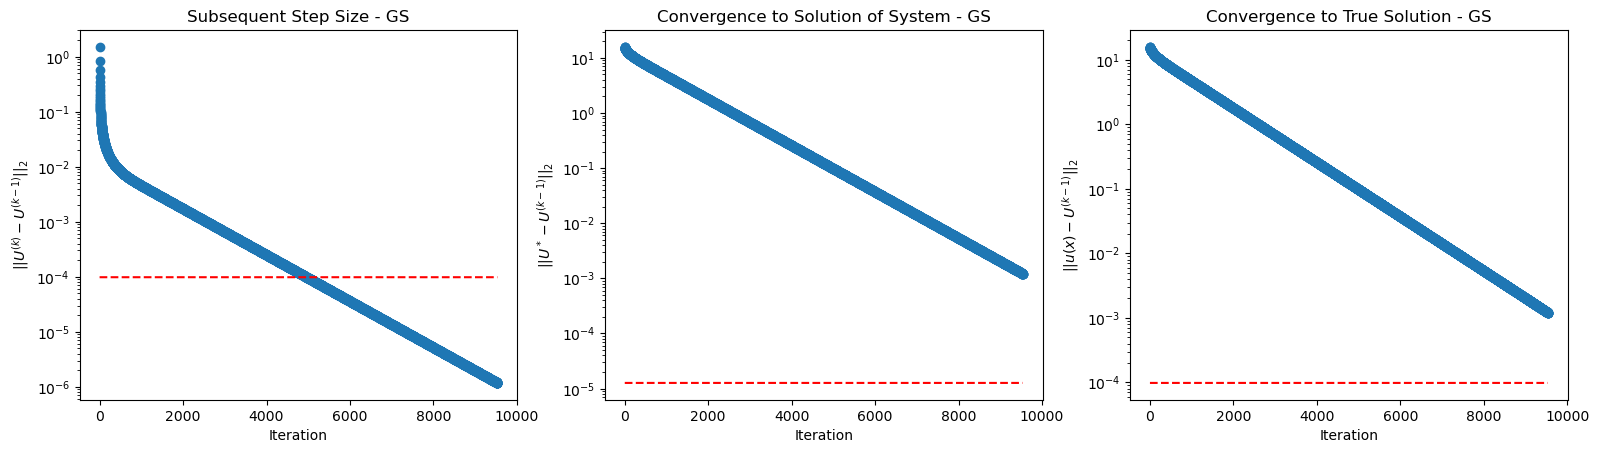

In [4]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 100
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Expected iterations needed
iterations_GS = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - numpy.pi**2 * delta_x**2))

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# Initial guess for iterations
U = numpy.zeros(m + 2)
U[0] = u_a
U[-1] = u_b
convergence_GS = numpy.zeros((iterations_GS, 2))
step_size_GS = numpy.zeros(iterations_GS)
success = False
for k in range(iterations_GS):
    U_old = U.copy()
    for i in range(1, m + 1):
        U[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0

    convergence_GS[k, 0] = numpy.linalg.norm(U_system - U, ord=2)
    convergence_GS[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)
    step_size_GS[k] = numpy.linalg.norm(U_old - U, ord=2)

# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_GS)), step_size_GS, 'o')
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 0], 'o')
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 1], 'o')
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

## Metode Pemisahan Matriks

Salah satu cara untuk melihat metode Jacobi dan Gauss–Seidel adalah sebagai pemisahan matriks $A$ sehingga

$$
A = M - N.
$$

Kemudian sistem $A U = b$ dapat dipandang sebagai

$$
M U - N U = b \Rightarrow M U = N U + b.
$$

Pembaruan yang dihasilkan untuk masing-masing metode kemudian menjadi

$$
U^{(k+1)} = M^{-1} N U^{(k)} + M^{-1} b = G U^{(k)} + c
$$

di mana $G$ disebut matriks iterasi dan $c = M^{-1} b$. Kita juga menginginkan

$$
u = G u + c
$$

di mana $u$ adalah solusi sebenarnya dari sistem awal $A u = b$. Dengan kata lain, $u$ merupakan titik tetap dari proses iterasi tersebut. Namun, apakah titik tetap ini stabil? Jika radius spektral memenuhi $\rho(G) < 1,$ maka dapat ditunjukkan bahwa proses iterasi tersebut memang stabil.

Perhatikan kemiripan antara analisis kestabilan yang kita lakukan sebelumnya yang melibatkan $||A^{-1}||$, dengan yang sekarang menggunakan $G = M^{-1}N$, yang mirip tetapi tidak sepenuhnya sama.

Untuk metode Jacobi, pemisahan matriksnya adalah

$$
    M = -\frac{2}{\Delta x^2} I, \quad \text{and}\quad N = -\frac{1}{\Delta x^2} \begin{bmatrix}
        0 & 1 & \\
        1 & 0 & 1 \\
          & \ddots & \ddots & \ddots \\
          & & 1 & 0 & 1 \\
          & &   & 1 & 0
    \end{bmatrix}
$$

(dengan tetap menggunakan masalah Poisson). Di sini, $M$ merupakan matriks diagonal, sehingga mudah untuk diselesaikan.

Untuk metode Gauss–Seidel, diperoleh

$$
    M = \frac{1}{\Delta x^2} \begin{bmatrix}
        -2 &  & \\
         1 & -2 &  \\
           & \ddots & \ddots \\
           & & 1 & -2 & \\
           & &   & 1 & -2
    \end{bmatrix} \quad \text{and} \quad 
    N = -\frac{1}{\Delta x^2} \begin{bmatrix}
         0 & 1 & \\
          & 0 & 1 \\
          & & \ddots & \ddots \\
           & &  & 0 & 1\\
           & &   &  & 0
    \end{bmatrix}
$$

### Kriteria Penghentian 

Berapa banyak \iterasi yang harus kita lakukan? Misalkan $E^{(k)}$ menyatakan galat (error) yang ada pada langkah ke-$k$. Jika kita ingin mengurangi galat awal $E^{(0)}$ hingga berorde $\epsilon$, maka diperoleh

$$
||E^{(k)}|| \approx \epsilon , ||E^{(0)}||.
$$

Dengan asumsi yang sesuai, kita dapat membatasi galat dalam norma-2 sebagai

$$
||E^{(k)}||_2 \leq \rho(G)^k , ||E^{(0)}||_2.
$$

di mana $\rho(G)$ adalah radius spektral dari matriks iterasi.

Kembali ke perkiraan jumlah iterasi, kita dapat menggabungkan dua persamaan yang melibatkan galat $E$ dengan mengambil batas $\Delta x \rightarrow 0$, sehingga kita dapat menuliskan

$$
k \approx \frac{\log \epsilon}{\log \rho(G)}
$$

dengan mempertimbangkan konvergensi galat.

Memilih nilai $\epsilon$ agak rumit, tetapi salah satu kriteria alami yang dapat digunakan adalah
$\epsilon = \mathcal{O}(\Delta x^2)$, karena diskretisasi awal kita memiliki akurasi orde dua.
Hal ini menghasilkan

$$
k = \frac{2 \log \Delta x}{\log \rho}.
$$

Persamaan ini juga memungkinkan kita untuk memperkirakan jumlah total operasi komputasi yang diperlukan.

Untuk metode Jacobi, radius spektral dari $G$ adalah

$$
\rho_J \approx 1 - \frac{1}{2}\pi^2 \Delta x^2.
$$

Sehingga diperoleh

$$
k = \mathcal{O}(m^2 \log m) \quad \text{ketika} \quad m \rightarrow \infty.
$$

Dengan menggabungkan hasil ini dengan jumlah operasi pada setiap iterasi yang telah dibahas sebelumnya, kita memperoleh bahwa metode Jacobi memerlukan kerja komputasi sebesar $\mathcal{O}(m^3 \log m)$
Hal ini menunjukkan bahwa metode tersebut tidak terlalu menjanjikan dari segi efisiensi komputasi. 

Untuk dua dimensi, diperoleh kompleksitas $\mathcal{O}(m^4 \log m)$,
sehingga bahkan jika dibandingkan dengan eliminasi Gauss, pendekatan ini masih tidak terlalu ideal.

Bagaimana dengan metode Gauss–Seidel? Di sini radius spektralnya kira-kira

$$
\rho_{GS} \approx 1 - \pi^2 \Delta x^2
$$

sehingga diperoleh

$$
k = \frac{2 \times \log \Delta x}{\log (1 - \pi^2 \Delta x^2)}.
$$

Namun, hal ini masih belum memberikan keuntungan yang berarti dibandingkan metode langsung. Meskipun demikian, hasil ini menunjukkan bahwa Gauss–Seidel memang konvergen lebih cepat, karena adanya perbedaan faktor 2 antara $\rho_J$ dan $\rho_{GS}$.

## Successive Overrelaxation (SOR)

Wah, itu agak mengecewakan, bukan? Metode-metode iteratif tersebut tampaknya tidak terlalu memberikan keuntungan.
Namun ternyata kita bisa mendapatkan hasil yang lebih baik dengan melakukan sedikit modifikasi pada metode Gauss–Seidel.

Jika kita melihat iterasi Gauss–Seidel, ternyata metode ini memang menggerakkan $U$ ke arah yang benar menuju solusi $u#, tetapi perubahannya sangat kecil (konservatif).
Sebagai gantinya, jika kita melakukan

$$\begin{aligned}
    U^{GS}_i &= \frac{1}{2} \left(U^{(k+1)}_{i-1} + U^{(k)}_{i+1} - \Delta x^2 f_i\right) \\
    U^{(k+1)}_i &= U_i^{(k)} + \omega \left( U_i^{GS} - U_i^{(k)}\right )
\end{aligned}$$

di mana kita dapat memilih nilai $\omega$, maka kita dapat memperoleh hasil yang jauh lebih baik.

Jika $\omega = 1$, maka kita kembali memperoleh metode Gauss–Seidel.

Jika $\omega < 1$, maka langkah yang diambil menjadi lebih kecil, sehingga konvergensinya lebih lambat(meskipun terkadang digunakan pada metode multigrid dengan nama underrelaxation).

Jika $\omega > 1$, maka kita melangkah lebih jauh dibandingkan yang disarankan oleh Gauss–Seidel, dan metode dengan $\omega > 1$ dikenal sebagai Successive Overrelaxation (SOR).

Dapat ditunjukkan bahwa jika dipilih nilai (\omega) sehingga $0 < \omega < 2$,
maka metode SOR akan konvergen.

Ternyata kita juga dapat menemukan nilai $\omega$ yang optimal untuk berbagai jenis masalah. Misalnya, untuk masalah Poisson pada berapa pun jumlah dimensi ruang, dapat ditunjukkan bahwa metode SOR akan konvergen secara optimal jika

$$
\omega_{opt} = \frac{2}{1 + \sin(\pi \Delta x)} \approx 2 - 2\pi \Delta x.
$$

Bagaimana dengan jumlah iterasinya? Kita dapat mengikuti pendekatan yang sama seperti sebelumnya, tetapi sekarang menggunakan radius spektral dari $G_{SOR}$, yaitu

$$
\rho = \omega_{opt} - 1 \approx 1 - 2 \pi \Delta x.
$$

Hal ini menghasilkan jumlah iterasi

$$
k = \mathcal{O}(m \log m)
$$

yang satu orde lebih baik dibandingkan metode Gauss–Seidel saja.


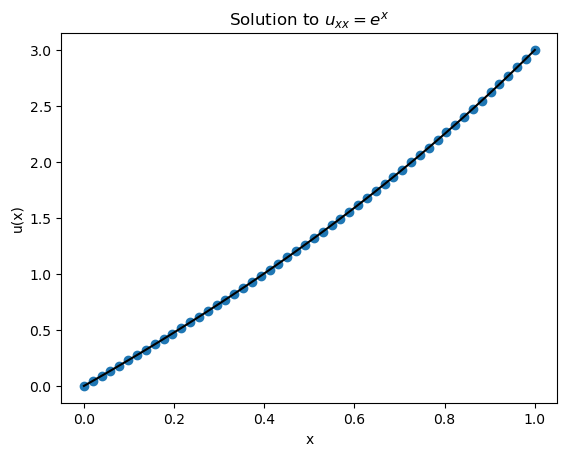

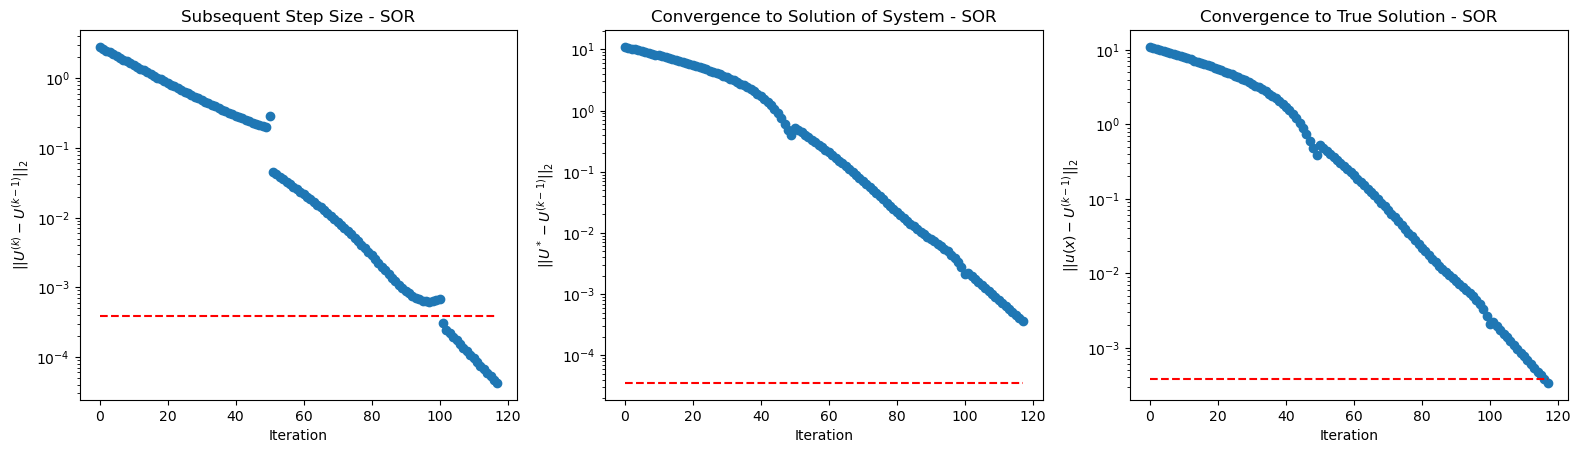

In [5]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# SOR parameter
omega = 2.0 / (1.0 + numpy.sin(numpy.pi * delta_x))

# Expected iterations needed
iterations_SOR = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 2.0 * numpy.pi * delta_x)) * 2

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# Initial guess for iterations
U = numpy.zeros(m + 2)
U[0] = u_a
U[-1] = u_b
step_size_SOR = numpy.zeros(iterations_SOR)
convergence_SOR = numpy.zeros((iterations_SOR, 2))
for k in range(iterations_SOR):
    U_old = U.copy()
    for i in range(1, m + 1):
        U_gs = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))
        U[i] += omega * (U_gs - U[i])

    step_size_SOR[k] = numpy.linalg.norm(U_old - U, ord=2)
    convergence_SOR[k, 0] = numpy.linalg.norm(U_system - U, ord=2)
    convergence_SOR[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)
        
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_SOR)), step_size_SOR, 'o')
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_SOR)), convergence_SOR[:, 0], 'o')
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_SOR)), convergence_SOR[:, 1], 'o')
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

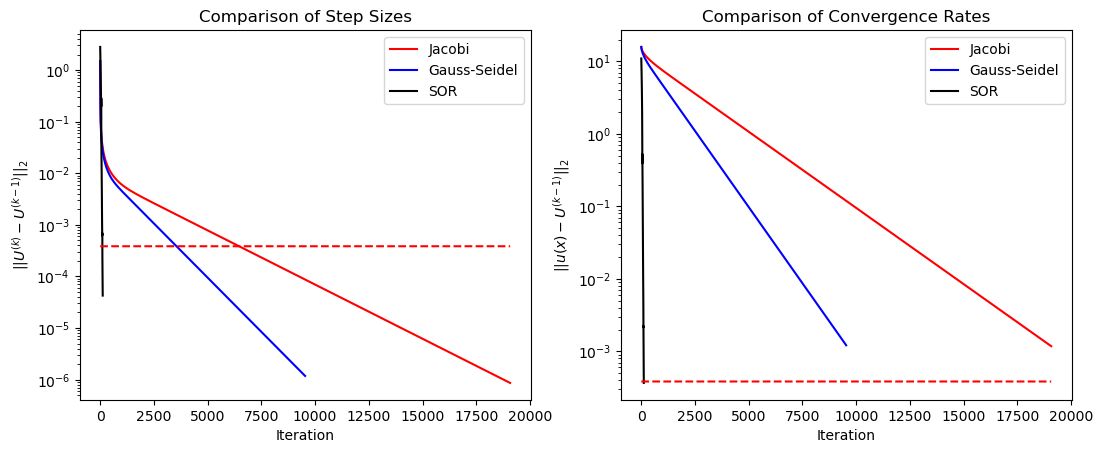

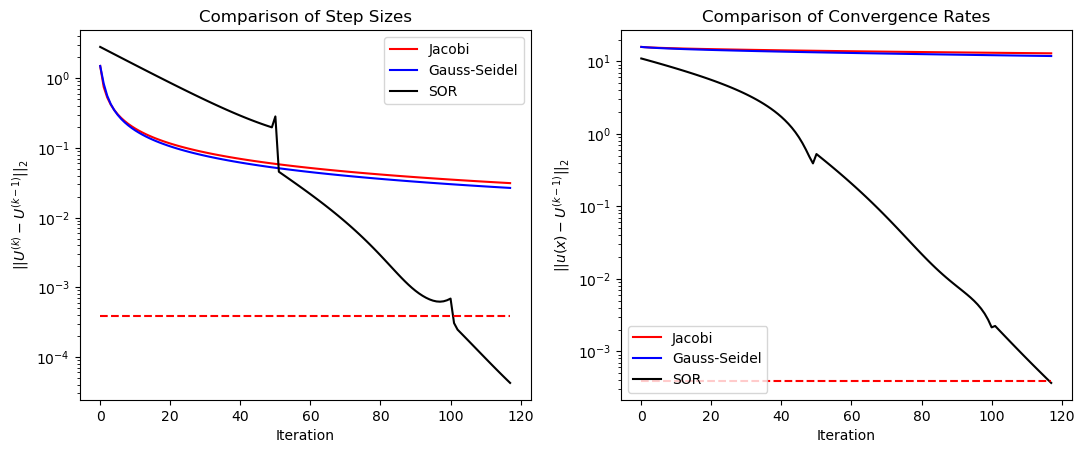

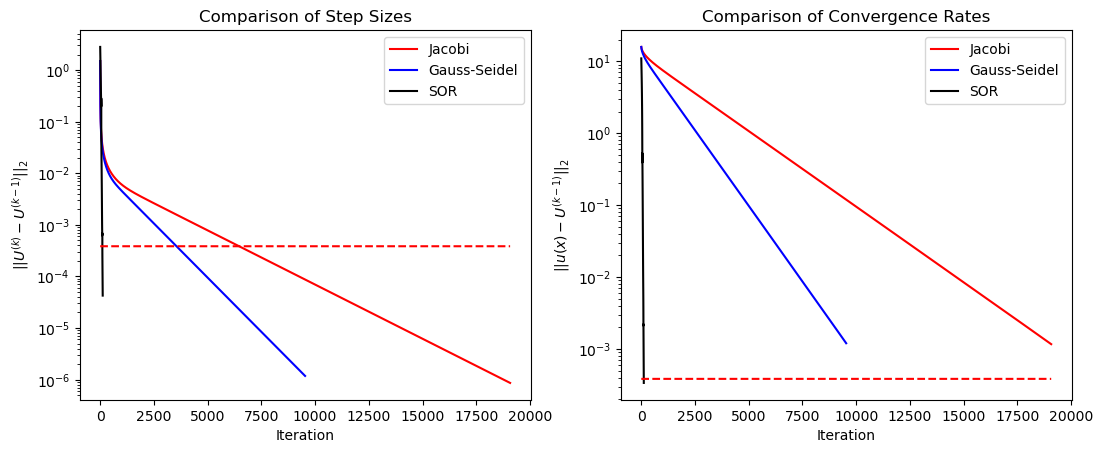

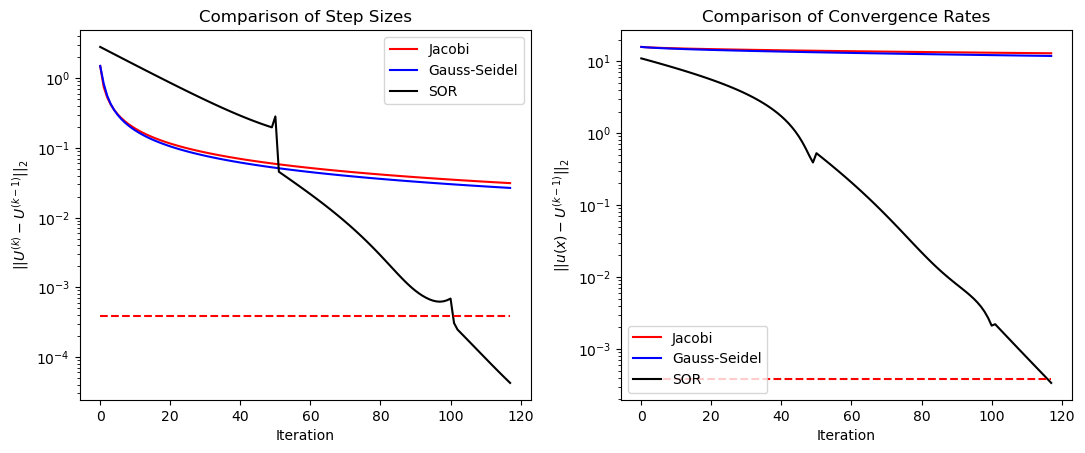

In [6]:
# Plotting all the convergence rates
for i in range(2):
    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)

    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(range(iterations_J), step_size_J, 'r', label="Jacobi")
    axes.semilogy(range(iterations_GS),  step_size_GS, 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  step_size_SOR, 'k', label="SOR")
    axes.semilogy(range(iterations_J), numpy.ones(iterations_J) * delta_x**2, 'r--')
    axes.legend(loc=1)
    axes.set_title("Comparison of Step Sizes")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(range(iterations_J), convergence_J[:, i], 'r', label="Jacobi")
    axes.semilogy(range(iterations_GS),  convergence_GS[:, i], 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  convergence_SOR[:, i], 'k', label="SOR")
    axes.semilogy(range(iterations_J), numpy.ones(iterations_J) * delta_x**2, 'r--')
    axes.legend(loc=1)
    axes.set_title("Comparison of Convergence Rates")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)

    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(range(iterations_SOR), step_size_J[:iterations_SOR], 'r', label="Jacobi")
    axes.semilogy(range(iterations_SOR),  step_size_GS[:iterations_SOR], 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  step_size_SOR, 'k', label="SOR")
    axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
    axes.legend(loc=1)
    axes.set_title("Comparison of Step Sizes")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(range(iterations_SOR), convergence_J[:iterations_SOR, i], 'r', label="Jacobi")
    axes.semilogy(range(iterations_SOR),  convergence_GS[:iterations_SOR, i], 'b', label="Gauss-Seidel")
    axes.semilogy(range(iterations_SOR),  convergence_SOR[:, i], 'k', label="SOR")
    axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2, 'r--')
    axes.legend(loc=3)
    axes.set_title("Comparison of Convergence Rates")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

## Metode Descent

Salah satu kasus khusus dari matriks memungkinkan penggunaan metode iteratif yang kuat untuk menemukan solusi. Suatu matriks dikatakan ymmetric positive definite (SPD) jika

$$
x^T A x > 0 \quad \forall \quad x \neq 0.
$$

Artinya, untuk setiap vektor $x$ yang tidak sama dengan nol, nilai $x^T A x$ selalu lebih besar dari nol.

Periksa apakah

$$
    A = \begin{bmatrix}
        2 &-1 &0 &0 \\
        -1 & 2 & -1 & 0 \\
        0 & -1 & 2 & -1 \\
        0 & 0 & -1 & 2
    \end{bmatrix}
$$

merupakan matriks symmetric positive definite (SPD).

Sekarang definisikan suatu fungsi $\phi : \mathbb{R}^m \rightarrow \mathbb{R}$ sebagai

$$
\phi(u) = \frac{1}{2} u^T A u - u^T f.
$$

Fungsi ini merupakan fungsi kuadratik terhadap variabel $u_i$. Pada kasus ketika $m = 2$, fungsi ini membentuk permukaan seperti mangkuk parabola. Karena ini adalah fungsi kuadratik, maka terdapat satu titik minimum yang unik, yaitu $u^\ast$.

Mari kita lihat bagaimana pendekatan masalah dengan cara ini dapat membantu kita:

Untuk kasus $m = 2$, tuliskan fungsi $\phi(u)$ secara eksplisit.

$$
    \phi(u) = \frac{1}{2} (A_{11} u_1^2 + A_{12} u_1 u_2 + A_{21} u_1 u_2 + A_{22} u^2_2) - u_1 f_1 - u_2 f_2
$$

Terjemahannya:

sifat apa dari matriks $A$ yang menyederhanakan ekspresi di atas?

Simetri! Hal ini menyiratkan bahwa $A_{21} = A_{12}$, sehingga ekspresi di atas dapat disederhanakan menjadi

$$
\phi(u) = \frac{1}{2}\left(A_{11} u_1^2 + 2 A_{12} u_1 u_2 + A_{22} u_2^2\right) - u_1 f_1 - u_2 f_2.
$$

Sekarang tuliskan dua persamaan yang jika dievaluasi pada $u^\ast$ bernilai nol secara identik, yang menyatakan bahwa $u^\ast$ meminimalkan $\phi(u)$.

Karena $u^\ast$ meminimalkan $\phi(u)$, kita tahu bahwa turunan pertama harus bernilai nol pada titik minimum:

  $$\begin{aligned}
       \frac{\partial \phi}{\partial u_1} &= A_{11} u_1 + A_{12} u_2 - f_1 = 0 \\
       \frac{\partial \phi}{\partial u_1} &= A_{21} u_1 + A_{22} u_2 - f_2 = 0
   \end{aligned}$$

Perhatikan bahwa persamaan-persamaan ini dapat dituliskan kembali sebagai

$$
A u = f.
$$

Artinya, menemukan solusi sistem linear $Au = f$ sama dengan mencari titik minimum dari fungsi kuadratik $\phi(u)$.

Oleh karena itu, mencari $\min \phi$ setara dengan menyelesaikan sistem $A u = f$!

Ini merupakan bentuk perumusan ulang yang cukup umum pada banyak masalah, di mana kadang-kadang lebih mudah memperlakukan suatu persamaan sebagai masalah minimisasi daripada menyelesaikannya secara langsung.

Perhatikan bahwa ini tidak sepenuhnya sama dengan matriks yang selama ini kita gunakan pada masalah Poisson, yang sebenarnya merupakan symmetric negative definite. Namun demikian, metode yang sama tetap dapat digunakan.

Dalam kasus ini, kita sebenarnya ingin mencari nilai maksimum dari $\phi$, bukan minimum. Selain perbedaan tersebut, semua prosesnya tetap sama.

Perhatikan juga bahwa jika $A$ indefinite, maka nilai eigen dari $A$ akan berubah tanda. Akibatnya, alih-alih memiliki minimum atau maksimum yang stabil, kita akan mendapatkan titik pelana yang jauh lebih sulit untuk ditangani (misalnya dapat ditangani dengan metode GMRES).

## Metode Steepest Descent

Sekarang kita beralih ke cara mencari $u^\ast$ yang meminimalkan fungsi $\phi(u)$. Pendekatan paling sederhana untuk ini disebut metode steepest descent, yaitu metode yang mencari arah gradien terbesar dari $\phi(u)$ lalu bergerak ke arah tersebut.

Secara matematis dituliskan sebagai

$$
u^{(k+1)} = u^{(k)} - \alpha^{(k)} \nabla \phi(u^{(k)})
$$

di mana $\alpha^{(k)}$ adalah ukuran langkah yang dipilih pada arah yang ingin kita tempuh.

Nilai $\alpha$ dapat dicari dengan

$$
\alpha^{(k)} = \min_{\alpha \in \mathbb{R}} \phi\left(u^{(k)} - \alpha \nabla \phi(u^{(k)})\right),
$$

yaitu nilai $\alpha$ yang membawa kita cukup jauh, sehingga jika kita bergerak lebih jauh lagi maka nilai $\phi$ akan mulai meningkat.

Hal ini menyiratkan bahwa
$\alpha^{(k)} \ge 0$
dan
$
\alpha^{(k)} = 0
$
hanya jika kita sudah berada di titik minimum $\phi$. Gradien dari $\phi$ dapat dihitung sebagai

$$
\nabla \phi(u^{(k)}) = A u^{(k)} - f \equiv -r^{(k)}
$$

di mana $r^{(k)}$ adalah residual yang didefinisikan sebagai

$$
r^{(k)} = f - A u^{(k)}.
$$

Kembali ke definisi $\alpha^{(k)}$, kita dapat menyimpulkan bahwa nilai $\alpha$ yang meminimalkan ekspresi tersebut adalah nilai yang memenuhi

$$
\frac{\text{d} \phi(\alpha)}{\text{d} \alpha} = 0.
$$

Untuk mencarinya, perhatikan bahwa

$$
    \phi(u + \alpha r) = \left(\frac{1}{2} u^T A u - u^T f \right) + \alpha(r^T A u - r^T f) + \frac{1}{2} \alpha^2 r^T A r
$$

sehingga turunannya menjadi

$$
    \frac{\text{d} \phi(\alpha)}{\text{d} \alpha} = r^T A u - r^T f + \alpha r^T A r
$$


Jika turunan ini disamakan dengan nol, maka diperoleh

$$
\alpha = \frac{r^T r}{r^T A r}.
$$


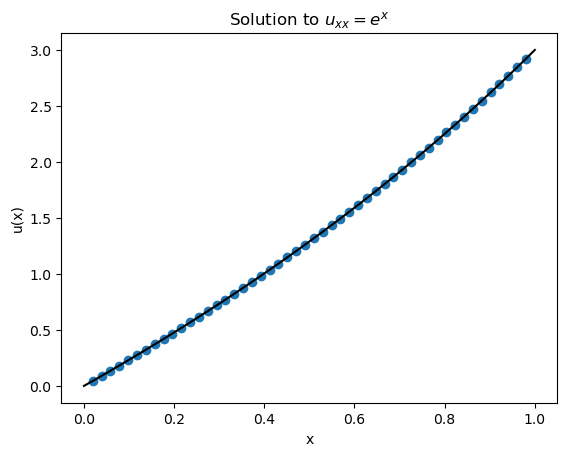

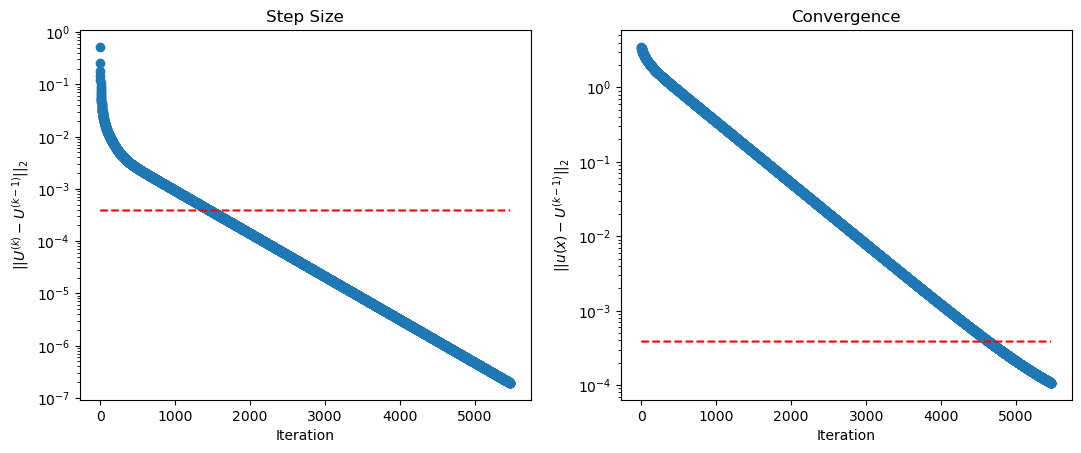

In [7]:
# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * 2.0, 0)
A += numpy.diag(-diagonal[:-1], 1)
A += numpy.diag(-diagonal[:-1], -1)

# Construct right hand side
b = -f(x)
b[0] += u_a / delta_x**2
b[-1] += u_b / delta_x**2

# Algorithm parameters
MAX_ITERATIONS = 10000
tolerance = 1e-3

# Solve system
U = numpy.empty(m)
convergence_SD = numpy.zeros(MAX_ITERATIONS)
step_size_SD = numpy.zeros(MAX_ITERATIONS)
success = False
for k in range(MAX_ITERATIONS):
    r = b - numpy.dot(A, U)
    if numpy.linalg.norm(r, ord=2) < tolerance:
        success = True
        break
        
    alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))
    U = U + alpha * r

    step_size_SD[k] = numpy.linalg.norm(alpha * r, ord=2)
    convergence_SD[k] = numpy.linalg.norm(u_true(x) - U, ord=2)
        
if not success:
    print("Iteration failed to converge!")
    print(convergence_SD[-1])
else:
    # Plot result
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, U, 'o', label="Computed")
    axes.plot(x_bc, u_true(x_bc), 'k', label="True")
    axes.set_title("Solution to $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    
    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(list(range(k)), step_size_SD[:k], 'o')
    axes.semilogy(list(range(k)), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Step Size")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(list(range(k)), convergence_SD[:k], 'o')
    axes.semilogy(list(range(k)), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Convergence")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")
    plt.show()

#### Konvergensi Metode Steepest Descent

Apa yang mengendalikan konvergensi metode steepest descent? Ternyata bentuk mangkuk parabola yang dibentuk oleh $\phi$ merupakan faktor utama yang menentukan kecepatan konvergensi metode steepest descent.

Sebagai contoh, jika $A$ adalah perkalian skalar dari matriks identitas, maka ellips yang terbentuk sebenarnya adalah lingkaran, dan steepest descent akan konvergen dalam $m$ langkah.

Jika $A$ tidak menghasilkan lingkaran, maka konvergensi bergantung pada rasio antara sumbu semi-mayor dan semi-minor dari ellips yang terbentuk dalam $m$ dimensi.

Hal ini dikendalikan oleh nilai eigen terkecil dan terbesar dari matriks $A$, sehingga metode steepest descent semakin sulit konvergen ketika $m$ meningkat, misalnya pada masalah Poisson.

Perlu dicatat bahwa ini juga berkaitan dengan kondisi matriks dalam $norma $\ell_2$.


![Ellipses](./images/ellipses.png)

Iteration count: 1
Iteration count: 8
Iteration count: 83


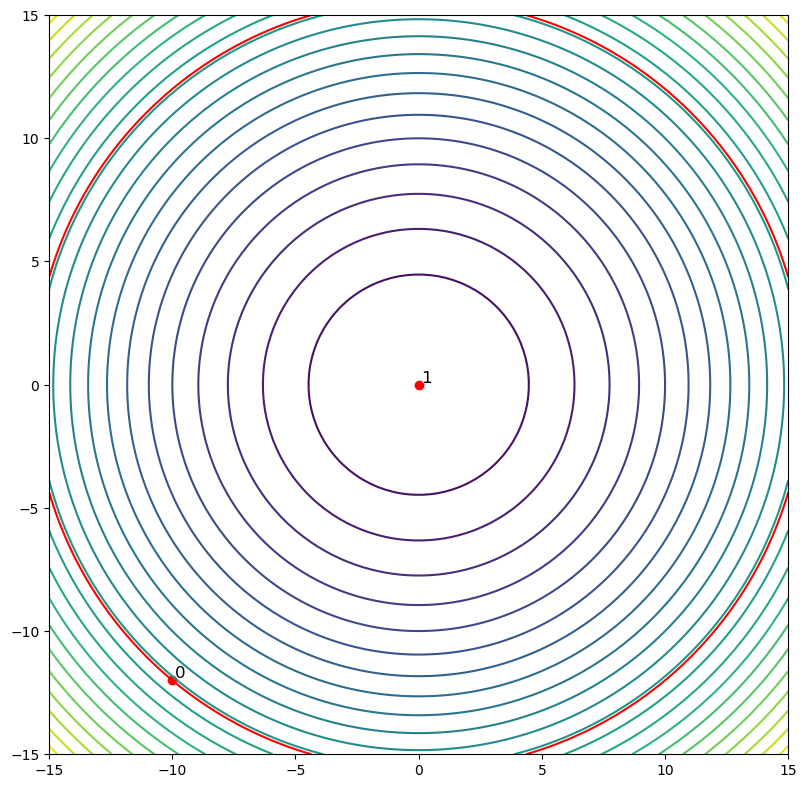

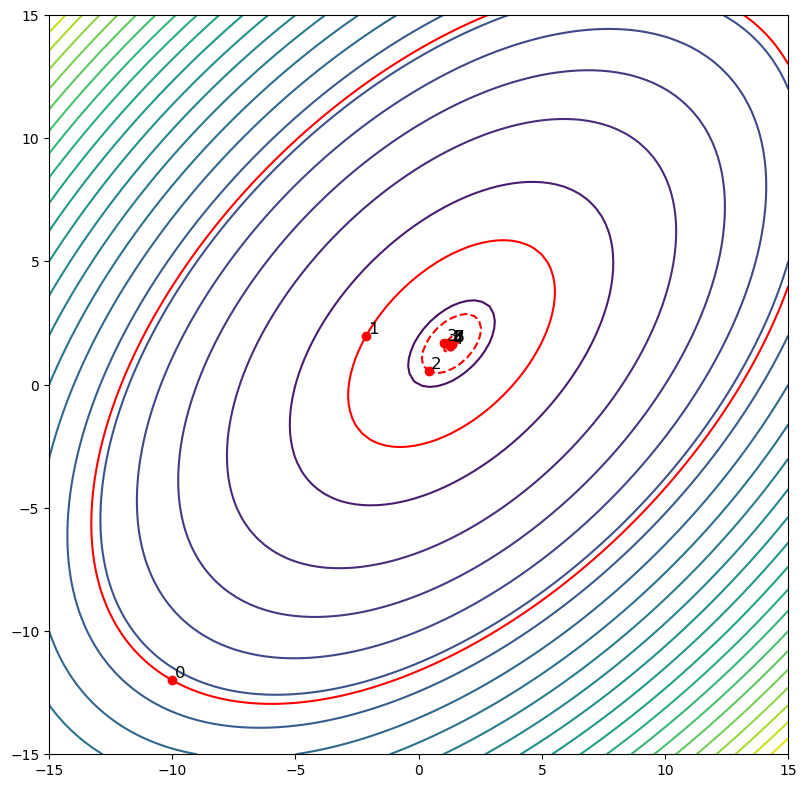

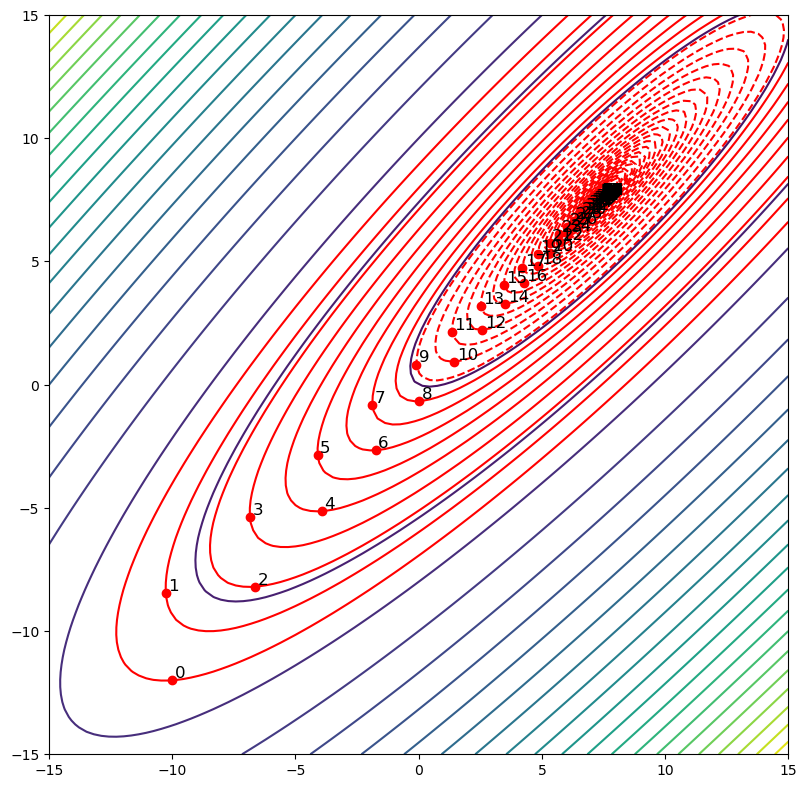

In [8]:
def steepest_descent(A, U, b, axes):
    MAX_ITERATIONS = 10000
    tolerance = 1e-3
    success = False
    iteration_locations = []
    for k in range(MAX_ITERATIONS):
        axes.text(U[0] + 0.1, U[1] + 0.1, str(k), fontsize=12)
        axes.plot(U[0], U[1], 'ro')
        iteration_locations.append(U)
        r = b - numpy.dot(A, U)
        if numpy.linalg.norm(r, ord=2) < tolerance:
            success = True
            break

        alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))
        U = U + alpha * r
        
    if success:
        return k, iteration_locations
    else:
        raise Exception("Iteration did not converge.")

phi = lambda X, Y, A: 0.5 * (A[0, 0] * X**2 + A[0, 1] * X * Y + A[1, 0] * X * Y + A[1, 1] * Y**2) - X * f[0] - Y * f[1]

x = numpy.linspace(-15, 15, 100)
y = numpy.linspace(-15, 15, 100)
X, Y = numpy.meshgrid(x, y)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.identity(2)
f = numpy.array([0.0, 0.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])
phi_levels.sort()
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')
axes.contour(X, Y, phi(X, Y, A), 25)
print("Iteration count: %s" % k)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.array([[2, -1], [-1, 2]])
f = numpy.array([1.0, 2.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])
phi_levels.sort()
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')
axes.contour(X, Y, phi(X, Y, A), 25)
print("Iteration count: %s" % k)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')
A = numpy.array([[2, -1.8], [-1.8, 2]])
f = numpy.array([1.0, 2.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])
phi_levels.sort()
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')
axes.contour(X, Y, phi(X, Y, A), 25)
print("Iteration count: %s" % k)


Setiap ellips ini terkait dengan struktur eigen dari $A$ sedemikian sehingga

$$
A v_j - f = \lambda_j (v_j - u^\ast)
$$

untuk beberapa $\lambda_j$.
Dengan mengetahui bahwa $A u^\ast = f$, diperoleh

$$
A (v_j - u^\ast) = \lambda_j (v_j - u^\ast).
$$

Dengan demikian, $(v_j - u^\ast)$ membentuk vektor-vektor eigen dari matriks $A$ dengan nilai eigen yang bersesuaian $\lambda_j$.

Jika seperangkat nilai $\lambda_j$ tertentu tidak berbeda tidak distinct, maka ellips tersebut sebenarnya menjadi lingkaran, menunjukkan bahwa setiap arah yang mengarah ke $u^\ast$ pada arah ini adalah sebuah vektor eigen (tidak unik dalam sub-ruang ini).

Kita juga dapat mengaitkan struktur eigen ini dan argumen geometris dengan angka kondisi matriks $\kappa$.
Misalkan $v_1$ dan $v_2$ adalah vektor-vektor yang terletak pada kurva $\phi(u) = 1$, maka kita memiliki

$$
\frac{1}{2} v_j^T A v_j - v_j^T A u^\ast = 1.
$$

Menggabungkan ekspresi ini dengan persamaan eigenvector sebelumnya dan mengambil inner product dengan vektor eigen $v_j - u^\ast$ menghasilkan

$$
||v_j - u^\ast||_2^2 = \frac{2 + (u^\ast)^T A u^\ast}{\lambda_j}.
$$

Kembali ke $v_1$ dan $v_2$, rasio norma mereka adalah

$$
\frac{||v_1 - u^\ast||_2}{||v_2 - u^\ast||_2} = \sqrt{\frac{\lambda_2}{\lambda_1}} = \sqrt{\kappa_2(A)}.
$$

Ekspresi terakhir ini menunjukkan bahwa semakin ellipsoidal sub-ruang ini, maka semakin sulit menyelesaikan sistem $A u^\ast = f$.

### Interpretasi Proyeksi

Salah satu cara untuk menafsirkan metode steepest descent adalah sebagai metode proyeksi iteratif.
Misalkan kita ingin menyelesaikan $A x = b, \quad A \in \mathbb{R}^{m \times m} \quad \text{dan} \quad b \in \mathbb{R}^m$.

Misalkan kita memiliki dua sub ruang di $\mathbb{R}^m$, yaitu
$\mathcal{K}$ sebagai sub ruang pencarian dan $\mathcal{L}$ sebagai sub ruang kendala. Kondisi

$$
b - A x \perp \mathcal{L}
$$

menunjukkan bahwa vektor residual $b - A x$ tegak lurus terhadap sub ruang $\mathcal{L}$.

Tapi bagaimana peran $\mathcal{K}$ dalam hal ini? Modifikasi pernyataan awal sehingga

$$
\tilde{x} \in \mathcal{K}
$$

dan kemudian

$$
b - A \tilde{x} \perp \mathcal{L}.
$$

Kondisi-kondisi ini dikenal sebagai kondisi Petrov–Galerkin.

Jika $\mathcal{K} = \mathcal{L}$, maka ini merupakan proyeksi ortogonal.

Dengan mengubah ini menjadi metode iteratif, misalkan tebakan awal kita adalah $x^{(0)}$, maka

$$
\tilde{x} \in x^{(0)} + \mathcal{K}
$$

sehingga

$$
b - A \tilde{x} \perp \mathcal{L}.
$$

Perhatikan bahwa ini menyiratkan bahwa kita sedang memperluas subruang pencarian dengan bagian dari $\text{span}(x^{(0)})$ yang tidak termasuk dalam $\mathcal{K}$.



Kita dapat menulis ulang ini dalam bentuk yang lebih menunjukkan arah iterasi dengan mendefinisikan

$$
\tilde{x} = x^{(0)} + \delta
$$

di mana $\delta \in \mathcal{K}$ adalah vektor langkah kita. Selain itu, beri indeks pada vektor residual sehingga kita memiliki

$$
r^{(k)} = b - A x^{(k)}
$$

pada langkah ke- $k$.

Kemudian kita merumuskan masalah baru sehingga

$$
r^{(0)} - A \delta \perp \mathcal{L},
$$

yang menghasilkan pernyataan mirip iterasi:

$$\begin{aligned}
    \tilde{x~} &= x^{(0)} + \delta, & \quad \quad & \delta \in \mathcal{K} \\
    (r^{(0)} - A \delta) \cdot w &= 0 & \quad \quad & \forall w \in \mathcal{L}
\end{aligned}$$



#### Contoh: Proyeksi Satu Dimensi

Metode proyeksi satu dimensi membangun $\mathcal{K}$ dan $\mathcal{L}$ sedemikian sehingga

$$
\mathcal{K} = \text{span}(v), \quad\quad \mathcal{L} = \text{span}(w)
$$

untuk dua vektor $v$ dan $w$.
Dalam kasus ini, kita dapat menulis update proyeksi sebagai

$$
x^{(k+1)} = x^{(k)} + \alpha r,
$$

di mana $r$ adalah residual, dan

$$
\alpha = \frac{r \cdot w}{A v \cdot w}.
$$

Dalam kasus steepest descent, kita ambil $v = w = r$, sehingga menghasilkan proyeksi ortogonal karena $\mathcal{K} = \mathcal{L}$.

Dengan sedikit generalisasi, kita dapat memandang metode steepest descent dalam kerangka proyeksi. Misalkan $\mathcal{K} = \mathcal{L}$ dan sekali lagi asumsikan $A$ adalah symmetric positive-definite. Definisikan galat pada langkah ke- $k$ sebagai

$$
E^{(k)} = x^\ast - x^{(k)}.
$$

Dalam kasus ini, pertimbangkan satu langkah dari $k = 0$ ke $k = 1$. Maka kita akan memiliki

$$
r^{(1)} = b - A (x^{(0)} + \delta) = r^{(0)} - A \delta,
$$

dan

$$
A E^{(1)} = r^{(1)} = A(E^{(0)} - \delta),
$$

di mana $\delta$ merupakan hasil dari proyeksi, sehingga

$$
(r^{(0)} - A \delta) \cdot w = 0, \quad \forall w \in \mathcal{K}.
$$
